# Reallocation sanity check on the native VIIRS grid

This notebook compares original strict-screened A2 radiance with the structural method aggregated back to the **same native cells**. Fine-scale outage analysis is deferred. All data are local; no TING inputs are used.

The original method smooths over a **500 m-radius neighborhood**, then applies structural gain. It is not guaranteed to preserve each native cell. We retain two controls: direct upsample-and-aggregate, and uniform smoothing. We test equivalence instead of forcing it.

The structural prior uses the original July 2026 Overture release. It is not an April 2025 inventory. The original structural formula and no-water reporting choice are retained, but the radiance uses this project's strict nightly QA. Run `scripts/run_reallocation_check.py` first, then use the project `.venv` kernel and Run All.

In [1]:
import os
import tempfile
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir())/'ntl-matplotlib'))
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rasterio.transform import Affine, rowcol
from IPython.display import display
%matplotlib inline
ROOT=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/'scripts/run_reallocation_check.py').exists())
sys.path.insert(0,str(ROOT))
from scripts.ingest_viirs import digest
OUT=ROOT/'data/published/reallocation_check'
manifest=json.loads((OUT/'manifest.json').read_text())
assert manifest['status']=='complete', 'Finish the reallocation pipeline first'
for name in ['comparison_arrays.npz','native_equivalence_by_date.csv','support_by_date.csv','validation_summary.csv','cells.csv','model_differences.csv']:
    assert digest(OUT/name)==manifest['output_sha256'][name], name
arrays=np.load(OUT/'comparison_arrays.npz',allow_pickle=False)
dates=pd.DatetimeIndex(arrays['dates']); cutoff=int(arrays['cutoff']); event_dates=dates[cutoff:]
cells=pd.read_csv(OUT/'cells.csv'); native=pd.read_csv(OUT/'native_equivalence_by_date.csv')
support=pd.read_csv(OUT/'support_by_date.csv'); validation=pd.read_csv(OUT/'validation_summary.csv')
differences=pd.read_csv(OUT/'model_differences.csv')
affine=Affine(*arrays['transform']); county=arrays['county']; common=arrays['common']
print('Kernel:',sys.executable)
print('Upstream commit:',manifest['contract']['upstream_commit'])
print('Structural release:',manifest['contract']['overture_release'])
print('Source period:',dates.min().date(),'to',dates.max().date())

Kernel: /home/daynan/research/ntl-outage-detection/.venv/bin/python
Upstream commit: 73ce981308ff40de8b66db3a97498f899cec7714
Structural release: 2026-07-22.0
Source period: 2025-02-05 to 2025-04-17


## Does aggregation reproduce A2?

All metrics below use the same usable cell-nights for all variants. MAE/RMSE/bias are in radiance units. The numerical equality check uses absolute tolerance 1e-5 plus relative tolerance 1e-5. This is a numerical diagnostic, not a threshold of scientific acceptability.

The upsample control quantifies differences caused by the projected 10 m workspace not nesting perfectly within native cells. Uniform smoothing shows the contribution of neighborhood averaging. The allocated field adds structural redistribution. None is rescaled to match A2.

In [2]:
rows=[]
for period, time_mask in [('baseline',np.arange(len(dates))<cutoff),('event',np.arange(len(dates))>=cutoff)]:
    use=common & time_mask[:,None]
    for name in ['upsample','uniform','allocated']:
        direct=arrays['direct'][use]; proxy=arrays[name][use]; error=proxy-direct
        rows.append({'period':period,'variant':name,'cell_nights':len(error),
                     'MAE':np.mean(np.abs(error)), 'RMSE':np.sqrt(np.mean(error**2)),
                     'bias':np.mean(error),'maximum_abs_error':np.max(np.abs(error)),
                     'numerically_equal_fraction':np.mean(np.isclose(proxy,direct,rtol=1e-5,atol=1e-5))})
display(pd.DataFrame(rows).round(6))
display(native.loc[native['date'].isin(['2025-04-03','2025-04-07','2025-04-08'])].round(5))

,period,variant,cell_nights,MAE,RMSE,bias,maximum_abs_error,numerically_equal_fraction
0,baseline,upsample,136391,0.006569,0.029535,0.000055,0.890356,0.030310
1,baseline,uniform,136391,0.459770,2.047523,0.002536,57.579393,0.010910
2,baseline,allocated,136391,0.476054,2.148724,0.003838,70.781985,0.001701
3,event,upsample,40021,0.003212,0.014618,0.000063,0.585139,0.074236
4,event,uniform,40021,0.223095,1.017565,0.006896,37.018394,0.017541
5,event,allocated,40021,0.233393,1.138610,0.007822,42.195012,0.004673


,date,variant,direct_usable_cells,common_cells,max_abs_error,mae,rmse,bias,area_weighted_bias,fraction_numerically_equal
171,2025-04-03,upsample,0,0,NaN,NaN,NaN,NaN,NaN,NaN
172,2025-04-03,uniform,0,0,NaN,NaN,NaN,NaN,NaN,NaN
173,2025-04-03,allocated,0,0,NaN,NaN,NaN,NaN,NaN,NaN
183,2025-04-07,upsample,5174,2619,0.03358,0.00261,0.00374,0.00006,0.00006,0.06796
184,2025-04-07,uniform,5174,2619,2.82599,0.17531,0.24890,0.00378,0.00378,0.01298
185,2025-04-07,allocated,5174,2619,5.96826,0.18557,0.29572,0.00593,0.00593,0.01298
186,2025-04-08,upsample,7307,5490,0.28337,0.00217,0.01014,0.00009,0.00009,0.00893
187,2025-04-08,uniform,7307,5490,18.40780,0.14917,0.67415,0.00889,0.00889,0.00018
188,2025-04-08,allocated,7307,5490,19.26909,0.15270,0.68647,0.00849,0.00849,0.00000


## Cost of requiring complete neighborhood and footprint support

The structural operator requires valid observations throughout its kernel; native aggregation then requires a complete footprint. Thus a clear native cell near cloud can become unavailable. All model comparisons below refit direct A2 on this same reduced mask. The original direct-only run had more training data and is not the matched comparator.

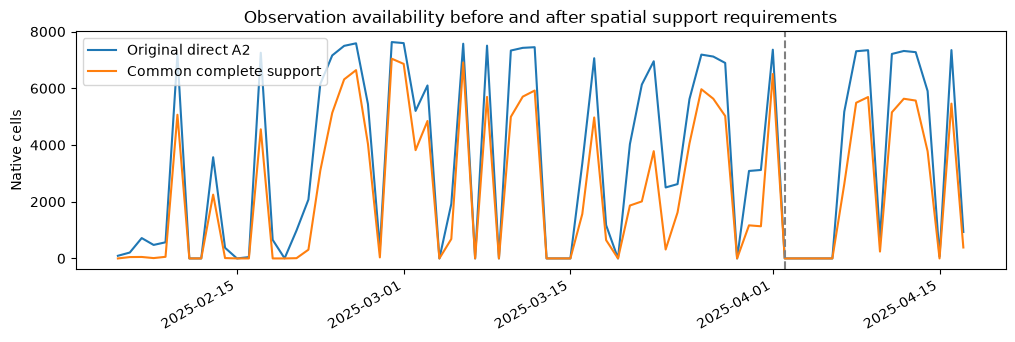

,date,direct_usable,common_usable
56,2025-04-02,0,0
57,2025-04-03,0,0
58,2025-04-04,0,0
59,2025-04-05,0,0
60,2025-04-06,0,0
61,2025-04-07,5174,2619
62,2025-04-08,7307,5490
63,2025-04-09,7344,5692
64,2025-04-10,713,242
65,2025-04-11,7212,5154


direct cells with >=10 baseline nights: 6938 median baseline count: 19.0
upsample cells with >=10 baseline nights: 6938 median baseline count: 19.0
uniform cells with >=10 baseline nights: 6938 median baseline count: 19.0
allocated cells with >=10 baseline nights: 6938 median baseline count: 19.0


In [3]:
fig,ax=plt.subplots(figsize=(12,3.5))
ax.plot(dates,support['direct_usable'],label='Original direct A2')
ax.plot(dates,support['common_usable'],label='Common complete support')
ax.axvline(event_dates[0],color='0.5',linestyle='--')
ax.set(ylabel='Native cells',title='Observation availability before and after spatial support requirements')
ax.legend();fig.autofmt_xdate();plt.show()
display(support.iloc[cutoff:])
for name in ['direct','upsample','uniform','allocated']:
    counts=arrays[f'{name}_training_count']
    print(name, 'cells with >=10 baseline nights:', int((counts>=10).sum()), 'median baseline count:', float(np.median(counts)))

## M0/M1 validation on matched observations

No model settings were tuned to make the methods agree. The original M0/M1 configuration is applied independently to each input, on identical valid dates. Seven-day and fourteen-day validation designs reuse target dates across designs; inspect them separately. Nominal interval coverage is 90%; observed undercoverage means that tail scores are not calibrated confidence measures.

In [4]:
def pooled(frame, keys):
    result=[]
    for key,group in frame.loc[frame.n>0].groupby(keys):
        if not isinstance(key,tuple): key=(key,)
        row=dict(zip(keys,key)); weights=group.n
        row['n']=int(weights.sum())
        for metric in ['mae','coverage90','below_q05','mean_interval_width','interval_score90']:
            row[metric]=np.average(group[metric],weights=weights)
        row['rmse']=np.sqrt(np.average(group.rmse**2,weights=weights))
        result.append(row)
    return pd.DataFrame(result)
display(pooled(validation[validation.stratum=='all'],['design','input_variant','method']).round(4))
display(pooled(validation[validation.stratum=='bright_ge5'],['design','input_variant','method']).round(4))
print('Brightness strata use each input’s training median; their membership can differ across inputs.')
display(differences[differences.field.isin(['center','residual','lower_tail'])].round(5))

,design,input_variant,method,n,mae,coverage90,below_q05,mean_interval_width,interval_score90,rmse
0,14d,allocated,M0,47435,0.4797,0.7847,0.0074,1.3401,3.4667,1.2124
1,14d,allocated,M1,47435,0.4646,0.8086,0.0122,1.4020,3.1912,1.1321
2,14d,direct,M0,47435,0.5923,0.8157,0.0163,1.7118,4.3933,2.0727
3,14d,direct,M1,47435,0.5851,0.8219,0.0208,1.7655,3.9862,1.9805
4,14d,uniform,M0,47435,0.4813,0.7851,0.0071,1.3488,3.4687,1.1966
5,14d,uniform,M1,47435,0.4665,0.8095,0.0119,1.4045,3.2134,1.1292
6,14d,upsample,M0,47435,0.5899,0.8152,0.0164,1.7039,4.3745,2.0563
7,14d,upsample,M1,47435,0.5827,0.8219,0.0205,1.7576,3.9695,1.9646
8,7d,allocated,M0,55411,0.4971,0.8075,0.0233,1.4218,3.4995,1.3986
9,7d,allocated,M1,55411,0.4864,0.8276,0.0280,1.4731,3.2695,1.3294


,design,input_variant,method,n,mae,coverage90,below_q05,mean_interval_width,interval_score90,rmse
0,14d,allocated,M0,1035,4.8903,0.6242,0.0628,10.8322,42.5371,7.4259
1,14d,allocated,M1,1035,4.5667,0.6377,0.0705,10.9843,38.3020,6.8754
2,14d,direct,M0,1038,8.4042,0.6156,0.1021,17.9797,77.4015,13.4103
3,14d,direct,M1,1038,8.2069,0.6686,0.1060,19.1590,63.1852,12.7884
4,14d,uniform,M0,1083,4.7369,0.6214,0.0637,10.6524,40.8021,7.1479
5,14d,uniform,M1,1083,4.4433,0.6380,0.0693,10.5665,37.5941,6.7051
6,14d,upsample,M0,1038,8.3395,0.6146,0.1031,17.8581,76.7959,13.2985
7,14d,upsample,M1,1038,8.1383,0.6724,0.1031,19.0089,62.6821,12.6798
8,7d,allocated,M0,1696,4.7340,0.6285,0.1055,10.4236,40.6521,7.4685
9,7d,allocated,M1,1696,4.4996,0.6362,0.1179,10.3034,37.8600,7.0757


Brightness strata use each input’s training median; their membership can differ across inputs.


,variant,method,field,n,mae,max_abs_error
0,upsample,M0,center,111008,0.00566,0.50573
6,upsample,M0,residual,38858,0.00381,0.70340
8,upsample,M0,lower_tail,38858,0.00163,0.10820
9,upsample,M1,center,111008,0.00382,0.39510
15,upsample,M1,residual,38858,0.00319,0.54422
17,upsample,M1,lower_tail,38858,0.00120,0.08880
18,uniform,M0,center,111008,0.36067,40.30980
24,uniform,M0,residual,38858,0.22755,42.71057
26,uniform,M0,lower_tail,38858,0.09623,0.98745
27,uniform,M1,center,111008,0.28918,29.32575


## Inspect one cell before interpreting the maps

The default cell is selected only by its direct pre-event median among cells supported on the common mask. Set a coordinate from QGIS to examine another cell. Points show common-support observations; curves show frozen normal predictions. The example focuses on direct versus allocated; both spatial controls remain available in the tables and arrays.

cell_id       h09v05_r0952_c0147
source_row                   952
source_col                   147
crop_row                      44
crop_col                      83
longitude             -89.385417
latitude                36.03125
area_m2               173679.882
Name: 4732, dtype: object


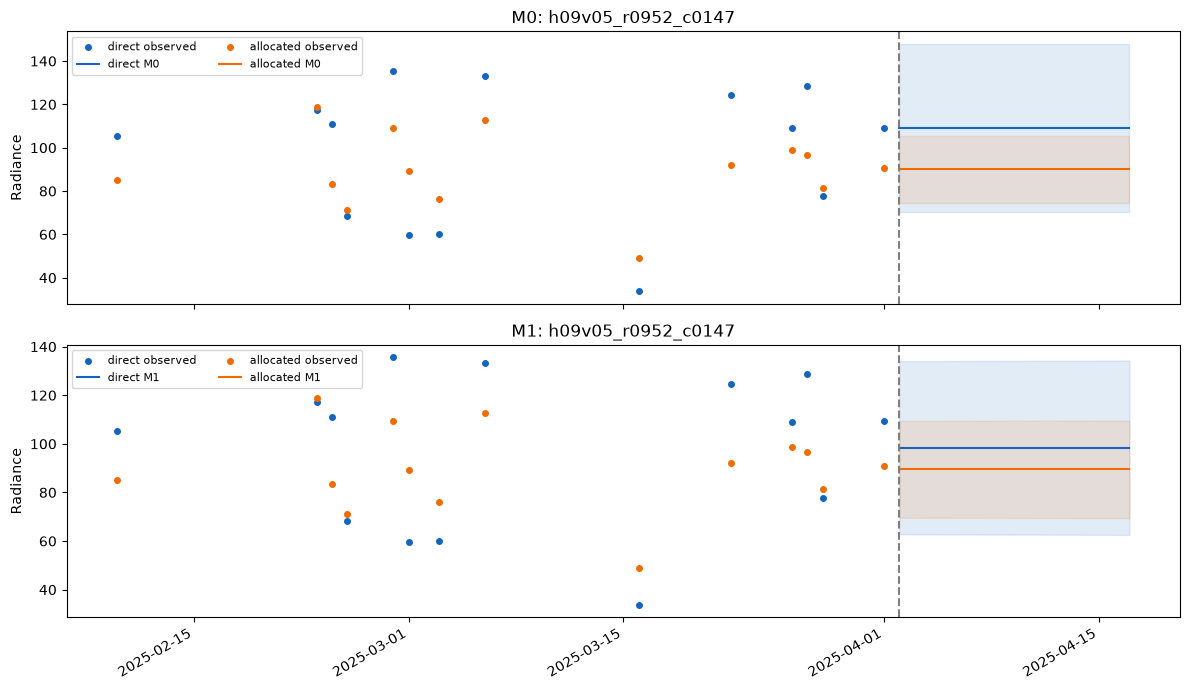

In [5]:
CELL_LON_LAT=None
with np.errstate(all='ignore'):
    import warnings
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore',message='All-NaN slice encountered')
        pre=np.nanmedian(np.where(common[:cutoff],arrays['direct'][:cutoff],np.nan),axis=0)
if CELL_LON_LAT is None:
    index=int(np.nanargmax(np.where(arrays['direct_training_count']>=10,pre,np.nan)))
else:
    r,col=rowcol(affine,*CELL_LON_LAT)
    match=cells.index[(cells.crop_row==r)&(cells.crop_col==col)]
    assert len(match)==1, 'Choose a cell center in Dyer'
    index=int(match[0])
print(cells.iloc[index])
fig,axes=plt.subplots(2,1,figsize=(12,7),sharex=True)
for ax,method in zip(axes,['M0','M1']):
    for variant,color in [('direct','#1565c0'),('allocated','#ef6c00')]:
        series=np.where(common[:,index],arrays[variant][:,index],np.nan)
        ax.scatter(dates,series,s=16,color=color,label=f'{variant} observed')
        ax.plot(event_dates,arrays[f'{variant}_{method}_center'][:,index],color=color,label=f'{variant} {method}')
        ax.fill_between(event_dates,arrays[f'{variant}_{method}_q05'][:,index],arrays[f'{variant}_{method}_q95'][:,index],color=color,alpha=.12)
    ax.axvline(event_dates[0],color='0.5',linestyle='--')
    ax.set(title=f'{method}: {cells.loc[index,"cell_id"]}',ylabel='Radiance')
    ax.legend(fontsize=8,ncol=2)
fig.autofmt_xdate();plt.tight_layout();plt.show()

## Native-grid comparison maps

No fine-resolution allocation is displayed here. Differences use common valid support. Blank areas represent missing observations or incomplete spatial support. Negative allocated-minus-direct values indicate redistribution away from the cell, not proof of an outage.

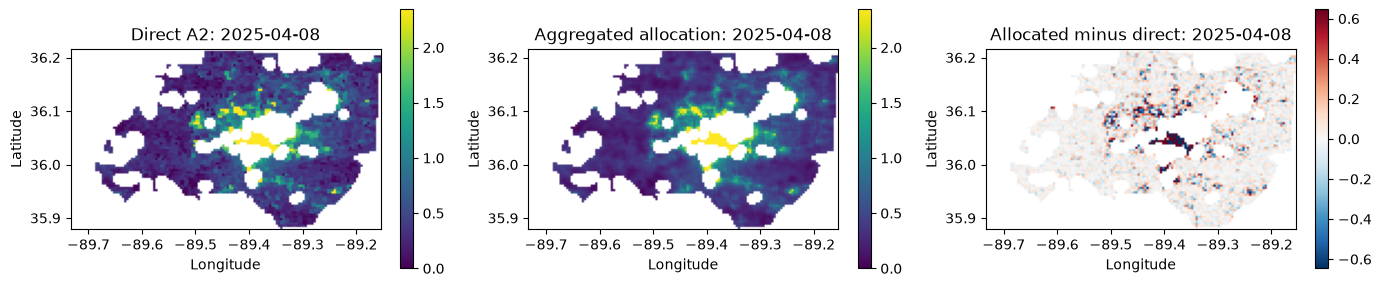

Display scales are capped at the 98th percentile; exported values are not clipped.


In [6]:
MAP_DATE='2025-04-08'
i=int(dates.get_loc(MAP_DATE))
def grid(value):
    result=np.full(county.shape,np.nan);result[county]=value;return result
h,w=county.shape
extent=[affine.c,affine.c+w*affine.a,affine.f+h*affine.e,affine.f]
keep=common[i]
direct=np.where(keep,arrays['direct'][i],np.nan)
allocated=np.where(keep,arrays['allocated'][i],np.nan)
error=allocated-direct
vmax=float(np.nanquantile(direct,.98)); bound=float(np.nanquantile(np.abs(error),.98))
fig,axes=plt.subplots(1,3,figsize=(14,4))
for ax,values,title,cm,low,high in zip(axes,[direct,allocated,error],['Direct A2','Aggregated allocation','Allocated minus direct'],['viridis','viridis','RdBu_r'],[0,0,-bound],[vmax,vmax,bound]):
    im=ax.imshow(grid(values),extent=extent,cmap=cm,vmin=low,vmax=high)
    ax.set(title=f'{title}: {MAP_DATE}',xlabel='Longitude',ylabel='Latitude')
    fig.colorbar(im,ax=ax,shrink=.7)
plt.tight_layout();plt.show()
print('Display scales are capped at the 98th percentile; exported values are not clipped.')

## QGIS and conclusions to assess

Mac mount: **`~/mnt/ntl/published/reallocation_check/`**.

- `native/allocated/YYYY-MM-DD.tif` is the proxy aggregated to the native grid.
- `native/direct/`, `native/upsample/`, and `native/uniform/` provide its controls.
- `allocated/M0/` and `allocated/M1/` contain the model reference, interval bounds, residual, and lower-tail diagnostic for each event date.
- `direct/M0/` and `direct/M1/` are the matched-support direct comparison.

Assess whether allocation changes exceed grid round-trip differences, where smoothing versus structural gain matters, and how much usable data are lost. Numerical inequivalence does not by itself show that either input is closer to true lighting. The structural method uses neighboring radiance, so it can spread or attenuate localized changes. TING evaluation and fine-scale outage analysis remain separate subsequent tasks.